# Hydrostatic Strain Channel ($\Gamma_1$)

**Silicon — hydrostatic deformation potential and its constitutive law**

This notebook covers the first of the three symmetry channels of the piezoresistive
response. Hydrostatic strain preserves the full cubic symmetry of the lattice, so it
cannot split the six equivalent $\Delta$ conduction valleys. Its entire effect runs
through the **band gap**: compressing or expanding the cell shifts $E_g$, which changes
how many carriers are thermally excited across it.

$$\varepsilon \;\longrightarrow\; \Delta E_g = a\,\varepsilon \;\longrightarrow\; n(T) \;\longrightarrow\; \sigma$$

### Scope caveat

In **doped** silicon the carrier concentration is pinned by the dopants, not by thermal
excitation across the gap. The $\Gamma_1$ contribution is therefore strongly suppressed
in the doped benchmark used for $\pi_{11}/\pi_{12}$. Everything below is **material
characterisation** — it is not an input to the doped-silicon device model.

### Outputs

| file | contents |
|---|---|
| `Hydrostatic_scalars.csv` | deformation potentials, equation of state, fit quality |
| `Hydrostatic_sweep.csv` | one row per DFT strain point |
| `figures/*.pdf`, `figures/*.png` | thesis figures |

---
## Part 0 — Setup

Imports, physical constants, and paths. `results_io` lives one directory up in `VASP/`
and anchors its own default paths to that location, so the relative hop here is only
needed to make the *module* importable.

In [1]:
import os
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('..')
from results_io import load_result, load_table, save_results, save_table

# ---- physical constants (universal; never stored as "results") ----
KB = 8.617333262e-5          # eV/K
T  = 300.0                   # K   modelling choice
KT = KB * T                  # eV

# ---- paths ----
BASE     = Path(".")
EQ_RUN   = Path("../Equilibirium_run/outputs/OUTCAR.band")
FIGDIR   = Path("figures"); FIGDIR.mkdir(exist_ok=True)
SCALARS  = "./Hydrostatic_scalars.csv"
SWEEP    = "./Hydrostatic_sweep.csv"

# ---- reference values for sanity checks ----
B_SI_LIT = 97.9              # GPa, experimental bulk modulus of Si

print("cwd            :", os.getcwd())
print("equilibrium run:", EQ_RUN, "->", "found" if EQ_RUN.exists() else "MISSING")
print("DPT results    :", "found" if os.path.exists("../DPT_results.csv") else "MISSING")

cwd            : /home/shahyusufsafi/Piezoresistivity-simulations/VASP/Hydrostatic_strain
equilibrium run: ../Equilibirium_run/outputs/OUTCAR.band -> found
DPT results    : found


---
## Part 1 — OUTCAR parser

One function pulls everything needed from a completed VASP run.

**On band-edge alignment.** Eigenvalues from separate runs sit on different absolute
energy scales, because the plane-wave basis fixes the potential only up to a constant
that changes with cell volume. Comparing $E_c$ or $E_v$ across strains therefore requires
a common reference. We use the **average electrostatic potential at the ion cores**,
which tracks that arbitrary offset:

$$E^{\text{aligned}} = E^{\text{raw}} - \langle V_{\text{core}}\rangle$$

The *gap* $E_g = E_c - E_v$ is alignment-independent — the offset cancels — so it is the
robust quantity. The individual aligned edges are more delicate and are reported with
that caveat in Part 4.

In [2]:
def extract_run(outcar_path):
    """Parse one VASP OUTCAR. Returns a dict of scalars, or raises if the file
    is missing or malformed."""
    outcar_path = Path(outcar_path)
    if not outcar_path.exists():
        raise FileNotFoundError(f"No OUTCAR at {outcar_path.resolve()}")
    text = outcar_path.read_text()

    E_f   = float(re.search(r"E-fermi\s*:\s*([-\d.]+)", text).group(1))
    V     = float(re.findall(r"volume of cell :\s*([\d.]+)", text)[-1])
    TOTEN = float(re.findall(r"free  energy   TOTEN\s*=\s*([-\d.]+)", text)[-1])
    P     = float(re.findall(r"external pressure =\s*([-\d.]+)", text)[-1])   # kBar

    # average electrostatic potential at the cores, for cross-run alignment
    pot_block = re.search(
        r"average \(electrostatic\) potential at core.*?\n.*?\n((?:\s+\d+\s+[-\d.]+)+)",
        text, re.DOTALL)
    V_avg = None
    if pot_block:
        nums = re.findall(r"-?\d+\.\d+", pot_block.group(1))
        V_avg = float(np.mean([float(x) for x in nums]))

    # eigenvalues: last SCF block only
    kpat = re.compile(
        r"k-point\s+\d+\s*:\s*([-\d.]+)\s+([-\d.]+)\s+([-\d.]+)\s*\n"
        r"\s*band No\..*?\n((?:\s*\d+\s+[-\d.]+\s+[-\d.]+\s*\n)+)")
    matches = list(kpat.finditer(text))
    nk = int(re.search(r"NKPTS\s*=\s*(\d+)", text).group(1))

    eig, occ = [], []
    for m in matches[-nk:]:
        e, o = [], []
        for line in m.group(4).strip().split("\n"):
            p = line.split()
            e.append(float(p[1])); o.append(float(p[2]))
        eig.append(e); occ.append(o)
    eig, occ = np.array(eig), np.array(occ)

    VBM = float(eig[occ > 0.5].max())
    CBM = float(eig[occ <= 0.5].min())

    # NOTE: `is not None`, not truthiness -- a legitimate V_avg of 0.0 must not
    # silently become None.
    aligned = V_avg is not None

    return {
        "E_fermi": E_f, "volume": V, "TOTEN": TOTEN, "pressure": P,
        "V_avg": V_avg, "VBM": VBM, "CBM": CBM, "gap": CBM - VBM,
        "VBM_aligned": VBM - V_avg if aligned else None,
        "CBM_aligned": CBM - V_avg if aligned else None,
    }

---
## Part 2 — Equilibrium reference

An independent unstrained run, used later to check that the $\varepsilon = 0$ point of
the sweep and the linear fit's intercept all agree on $E_g(0)$.

In [3]:
r_eq = extract_run(EQ_RUN)

print("Equilibrium reference run")
print("-" * 46)
for k, v in r_eq.items():
    print(f"  {k:15s} = {v}")

V0 = r_eq["volume"]

Equilibrium reference run
----------------------------------------------
  E_fermi         = 6.0589
  volume          = 40.03
  TOTEN           = -7.14297125
  pressure        = 159.48
  V_avg           = -83.2423
  VBM             = 5.8325
  CBM             = 6.4056
  gap             = 0.5731000000000002
  VBM_aligned     = 89.0748
  CBM_aligned     = 89.64789999999999


---
## Part 3 — Load the strain sweep

Every strained run is parsed **once** here, into a single `rows` list that is the sole
source of truth for the rest of the notebook. Downstream cells derive their arrays from
`rows` rather than re-reading the OUTCARs.

The applied deformation is isotropic **linear** strain on each lattice vector,

$$a_i \to (1+\varepsilon)\,a_i \qquad\Longrightarrow\qquad V = V_0 (1+\varepsilon)^3,$$

so the volumetric strain is $\Delta V/V \simeq 3\varepsilon$. This factor of three matters
in Part 4 and is the single easiest thing to get wrong in this channel.

In [4]:
strains = np.asarray(load_result("strains"), dtype=float)
print("strain grid:", strains)

rows = []
for s in strains:                     # NOTE: loop var is `s`, never `eps`
    r = extract_run(BASE / f"eps_{s:+.4f}" / "OUTCAR")
    r["eps"] = float(s)
    rows.append(r)

# ---- the canonical arrays; everything downstream uses these ----
eps      = np.array([r["eps"]         for r in rows])
VBM      = np.array([r["VBM_aligned"] for r in rows])
CBM      = np.array([r["CBM_aligned"] for r in rows])
gap      = np.array([r["gap"]         for r in rows])
volume   = np.array([r["volume"]      for r in rows])
P_kbar   = np.array([r["pressure"]    for r in rows])
P_GPa    = P_kbar * 0.1
TOTEN    = np.array([r["TOTEN"]       for r in rows])
E_fermi  = np.array([r["E_fermi"]     for r in rows])
V_avg    = np.array([r["V_avg"]       for r in rows])

# ---- verify the strain was applied as expected ----
vol_expected = V0 * (1 + eps) ** 3
assert np.allclose(volume, vol_expected, rtol=1e-3), \
    "cell volumes do not follow V0(1+eps)^3 -- check how the strain was applied"

print(f"\n{len(rows)} runs loaded, volumes consistent with V0(1+eps)^3")
print(pd.DataFrame({"eps": eps, "volume": volume, "gap": gap,
                    "P (GPa)": P_GPa}).to_string(index=False))

strain grid: [-0.01  -0.005 -0.002  0.     0.002  0.005  0.01 ]

7 runs loaded, volumes consistent with V0(1+eps)^3
   eps  volume    gap  P (GPa)
-0.010   38.84 0.5169   31.637
-0.005   39.43 0.5451   29.307
-0.002   39.79 0.5621   27.972
 0.000   40.03 0.5731   27.107
 0.002   40.27 0.5841   26.263
 0.005   40.63 0.6004   25.032
 0.010   41.24 0.6264   23.077


---
## Part 4 — Deformation potentials

Linear fits of the aligned band edges and of the gap against strain:

$$a_c = \frac{dE_c}{d\varepsilon}, \qquad
  a_v = \frac{dE_v}{d\varepsilon}, \qquad
  a_{\text{gap}} = \frac{dE_g}{d\varepsilon} = a_c - a_v$$

### Strain convention — read this before using $a$ anywhere

The literature hydrostatic deformation potential is conventionally defined **per unit
volumetric strain**,

$$a \equiv \frac{dE_g}{d(\Delta V/V)},$$

whereas the fit below is **per unit linear strain**. Since $\Delta V/V = 3\varepsilon$,

$$a_{\text{gap}}^{(\text{linear})} = 3\,a^{(\text{volumetric})}.$$

Both describe the same physics; mixing them costs a factor of three. The check printed
below compares this notebook's linear-strain slope against the value stored in
`DPT_results.csv` and reports the ratio explicitly, so the convention in force is never
ambiguous.

### Caveat on the individual edges

$a_c$ and $a_v$ rely on core-potential alignment, which under *hydrostatic* strain is
itself volume-dependent — the core potential shifts with the cell. Absolute deformation
potentials obtained this way are approximate and should be quoted with that caveat.
$a_{\text{gap}}$ needs no alignment at all and is the quantity to trust.

In [5]:
a_c   = np.polyfit(eps, CBM, 1)[0]
a_v   = np.polyfit(eps, VBM, 1)[0]
a_gap, Eg0_fit = np.polyfit(eps, gap, 1)      # slope, intercept

a_dpt = load_result("a")                       # value stored by DPT.ipynb

print("Deformation potentials (per unit LINEAR strain)")
print("-" * 58)
print(f"  a_c   = dE_c/deps    = {a_c:+8.4f} eV      [alignment-dependent]")
print(f"  a_v   = dE_v/deps    = {a_v:+8.4f} eV      [alignment-dependent]")
print(f"  a_gap = dE_g/deps    = {a_gap:+8.4f} eV      [alignment-free]")
print(f"  a_c - a_v            = {a_c - a_v:+8.4f} eV      "
      f"[closure: {abs((a_c - a_v) - a_gap)*1000:.3f} meV]")

print("\nStrain convention check")
print("-" * 58)
print(f"  a from DPT_results.csv  = {a_dpt:+8.4f} eV")
print(f"  a_gap / a_dpt           = {a_gap / a_dpt:8.4f}")
if abs(a_gap / a_dpt - 3.0) < 0.05:
    print("  -> ratio is 3: DPT stores the VOLUMETRIC convention,")
    print("     this notebook fits the LINEAR one. Same physics.")
    print(f"     volumetric a = a_gap/3 = {a_gap/3:+.4f} eV")
elif abs(a_gap / a_dpt - 1.0) < 0.05:
    print("  -> ratio is 1: both use the same convention.")
else:
    print("  -> ratio is neither 1 nor 3. Investigate before using either value.")

print("\nGap at zero strain")
print("-" * 58)
print(f"  from linear fit         = {Eg0_fit:.4f} eV")
print(f"  from equilibrium run    = {r_eq['gap']:.4f} eV   "
      f"[{abs(Eg0_fit - r_eq['gap'])*1000:.2f} meV apart]")

Deformation potentials (per unit LINEAR strain)
----------------------------------------------------------
  a_c   = dE_c/deps    =  +8.8566 eV      [alignment-dependent]
  a_v   = dE_v/deps    =  +3.3702 eV      [alignment-dependent]
  a_gap = dE_g/deps    =  +5.4864 eV      [alignment-free]
  a_c - a_v            =  +5.4864 eV      [closure: 0.000 meV]

Strain convention check
----------------------------------------------------------
  a from DPT_results.csv  =  +1.8288 eV
  a_gap / a_dpt           =   3.0000
  -> ratio is 3: DPT stores the VOLUMETRIC convention,
     this notebook fits the LINEAR one. Same physics.
     volumetric a = a_gap/3 = +1.8288 eV

Gap at zero strain
----------------------------------------------------------
  from linear fit         = 0.5726 eV
  from equilibrium run    = 0.5731 eV   [0.51 meV apart]


---
## Part 5 — How linear is it?

The deformation-potential *ansatz* assumes $E_g(\varepsilon)$ is linear over the range of
interest. Residuals against the linear fit test that directly; a quadratic fit quantifies
whatever curvature remains.

In [6]:
gap_fit   = a_gap * eps + Eg0_fit
residuals = gap - gap_fit

print("Residuals (DFT - linear fit)")
print("-" * 40)
for e_i, r_i in zip(eps, residuals):
    print(f"  eps = {e_i*100:+5.1f}% :  {r_i*1000:+7.2f} meV")

resid_max = np.abs(residuals).max() * 1000.0
resid_rms = np.sqrt(np.mean(residuals ** 2)) * 1000.0
print(f"\n  max |residual| = {resid_max:.2f} meV")
print(f"  RMS residual   = {resid_rms:.2f} meV")

quad = np.polyfit(eps, gap, 2)
print(f"\nQuadratic fit: {quad[0]:+.2f} eps^2 {quad[1]:+.2f} eps {quad[2]:+.4f}")
print(f"  curvature coefficient = {quad[0]:+.2f} eV")
print(f"  curvature contribution at eps = 1%: "
      f"{abs(quad[0]) * 1e-4 * 1000:.2f} meV "
      f"({abs(quad[0]) * 1e-4 / abs(a_gap * 1e-2) * 100:.1f}% of the linear term)")

Residuals (DFT - linear fit)
----------------------------------------
  eps =  -1.0% :    -0.82 meV
  eps =  -0.5% :    -0.05 meV
  eps =  -0.2% :    +0.49 meV
  eps =  +0.0% :    +0.51 meV
  eps =  +0.2% :    +0.54 meV
  eps =  +0.5% :    +0.38 meV
  eps =  +1.0% :    -1.05 meV

  max |residual| = 1.05 meV
  RMS residual   = 0.62 meV

Quadratic fit: -14.85 eps^2 +5.49 eps +0.5731
  curvature coefficient = -14.85 eV
  curvature contribution at eps = 1%: 1.48 meV (2.7% of the linear term)


---
## Part 6 — Equation of state

Each OUTCAR also reports the stress, so two further quantities come for free.

**Pressure derivative of the gap**, fitted *directly* from $E_g$ against $P$ rather than
inferred through $a$ and a separately obtained bulk modulus:

$$\frac{dE_g}{dP} \quad\text{[eV/GPa]}$$

**Bulk modulus** from the computed equation of state:

$$B = -V \frac{dP}{dV}$$

This second number is a genuine diagnostic rather than a result: silicon's experimental
value is $\approx 98$ GPa, and a large deviation — or a large residual pressure at
$\varepsilon = 0$ — indicates Pulay stress from an under-converged plane-wave cutoff, or a
reference cell that is not at the PBE equilibrium volume. Either would bias every stress
number downstream, so it is worth knowing.

In [7]:
# --- dEg/dP, fitted directly ---
dEg_dP = np.polyfit(P_GPa, gap, 1)[0]                  # eV/GPa

# --- bulk modulus from -V dP/dV ---
dP_dV = np.polyfit(volume, P_GPa, 1)[0]                # GPa / A^3
B_eos = -V0 * dP_dV                                    # GPa

# --- residual pressure at the reference volume ---
P_at_zero = P_GPa[np.isclose(eps, 0.0)]
P_resid   = float(P_at_zero[0]) if len(P_at_zero) else np.nan

print("Equation of state")
print("-" * 62)
print(f"  dEg/dP (direct fit)     = {dEg_dP:+.5f} eV/GPa "
      f"= {dEg_dP*100:+.2f} meV/kbar")
print(f"  dEg/dP (= -a_vol / B)   = {-(a_gap/3)/B_eos:+.5f} eV/GPa   [consistency]")
print(f"  B  (from -V dP/dV)      = {B_eos:8.1f} GPa")
print(f"  B  (Si, experiment)     = {B_SI_LIT:8.1f} GPa")
print(f"  deviation               = {(B_eos/B_SI_LIT - 1)*100:+.1f} %")
print(f"\n  residual pressure at eps = 0: {P_resid:+.2f} GPa")

if abs(B_eos / B_SI_LIT - 1) > 0.15 or abs(P_resid) > 1.0:
    print("\n  WARNING: the computed stress is inconsistent with experiment.")
    print("  A relaxed cell should sit near zero pressure and reproduce B to a few %.")
    print("  Likely causes, in order of probability:")
    print("    1. ENCUT too low -> Pulay stress (check convergence of P vs ENCUT)")
    print("    2. reference cell at the experimental, not the PBE-relaxed, volume")
    print("    3. k-mesh too coarse for stress (stress converges slower than energy)")
    print("  The GAP results above are unaffected -- eigenvalues converge far faster")
    print("  than stress. Only pressure-referenced quantities are in question.")

Equation of state
--------------------------------------------------------------
  dEg/dP (direct fit)     = -0.01281 eV/GPa = -1.28 meV/kbar
  dEg/dP (= -a_vol / B)   = -0.01282 eV/GPa   [consistency]
  B  (from -V dP/dV)      =    142.7 GPa
  B  (Si, experiment)     =     97.9 GPa
  deviation               = +45.8 %

  residual pressure at eps = 0: +27.11 GPa

  A relaxed cell should sit near zero pressure and reproduce B to a few %.
  Likely causes, in order of probability:
    1. ENCUT too low -> Pulay stress (check convergence of P vs ENCUT)
    2. reference cell at the experimental, not the PBE-relaxed, volume
    3. k-mesh too coarse for stress (stress converges slower than energy)
  The GAP results above are unaffected -- eigenvalues converge far faster
  than stress. Only pressure-referenced quantities are in question.


---
## Part 7 — Figure: band edges and gap

Left: the aligned conduction and valence edges, with the equilibrium run overlaid as
horizontal reference lines. Right: the gap with its linear fit — the slope of that line
*is* $a_{\text{gap}}$.

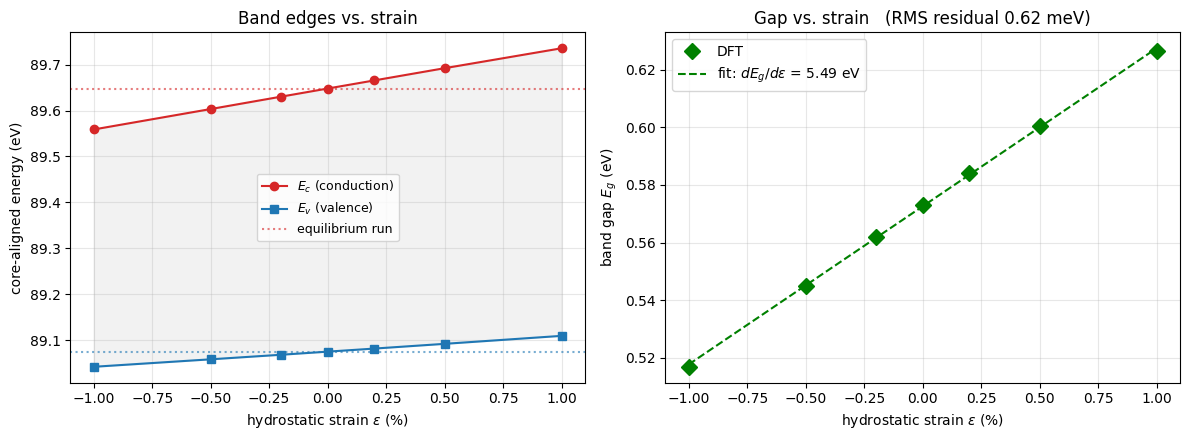

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].plot(eps*100, CBM, 'o-', color='tab:red',  label=r'$E_c$ (conduction)')
ax[0].plot(eps*100, VBM, 's-', color='tab:blue', label=r'$E_v$ (valence)')
ax[0].axhline(r_eq["CBM_aligned"], color='tab:red',  ls=':', alpha=0.6,
              label='equilibrium run')
ax[0].axhline(r_eq["VBM_aligned"], color='tab:blue', ls=':', alpha=0.6)
ax[0].fill_between(eps*100, VBM, CBM, alpha=0.10, color='grey')
ax[0].set_xlabel(r'hydrostatic strain $\varepsilon$ (%)')
ax[0].set_ylabel('core-aligned energy (eV)')
ax[0].set_title('Band edges vs. strain')
ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)

ax[1].plot(eps*100, gap, 'D', color='green', ms=8, label='DFT')
ax[1].plot(eps*100, gap_fit, '--', color='green',
           label=rf'fit: $dE_g/d\varepsilon$ = {a_gap:.2f} eV')
ax[1].set_xlabel(r'hydrostatic strain $\varepsilon$ (%)')
ax[1].set_ylabel(r'band gap $E_g$ (eV)')
ax[1].set_title(rf'Gap vs. strain   (RMS residual {resid_rms:.2f} meV)')
ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(FIGDIR / "gap_vs_strain.pdf", bbox_inches="tight")
fig.savefig(FIGDIR / "gap_vs_strain.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Part 8 — Band structure across the three channels

Overlaid band structures at $\varepsilon = -1\%,\,0,\,+1\%$ for each strain channel.

Under **hydrostatic** strain the bands move rigidly and the six $\Delta$ valleys stay
degenerate — cubic symmetry is untouched. Under **uniaxial** strain that degeneracy lifts
into $2+4$, which is the mechanism the $\Gamma_{12}$ channel exploits. **Shear** leaves the
$\Delta$ valleys degenerate again, which is exactly why $\pi_{44}$ vanishes under
constant-$\tau$ RTA.

Channels whose directories are absent are skipped rather than raising.

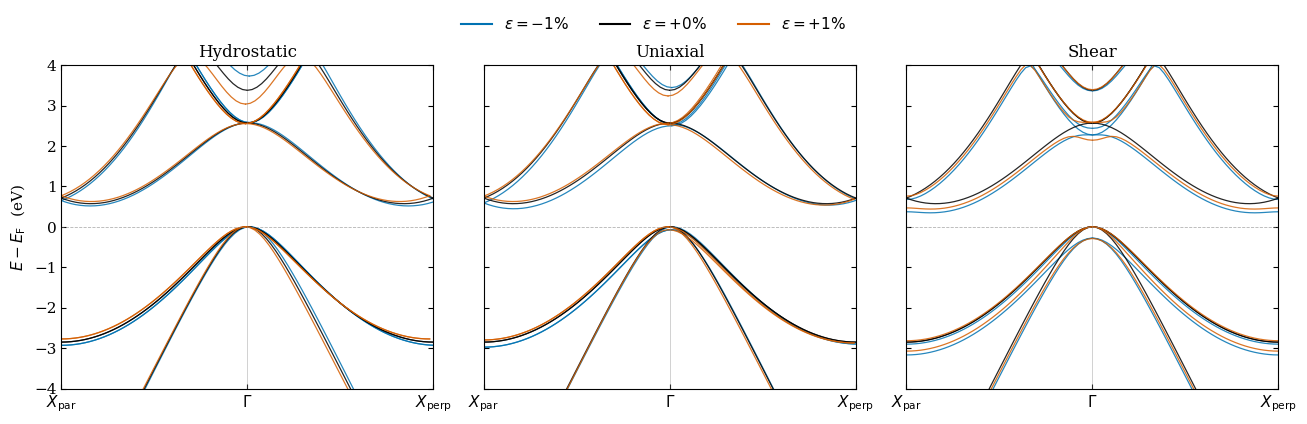

In [9]:
from pymatgen.io.vasp import BSVasprun
from pymatgen.electronic_structure.plotter import BSPlotter
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.size": 11, "font.family": "serif", "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
})

# NOTE: `strains_plot`, NOT `strains` -- shadowing the sweep grid silently
# corrupted every downstream cell in the previous version of this notebook.
strains_plot = [-0.010, 0.000, 0.010]
colors       = ["#0072B2", "#000000", "#D55E00"]
channels     = [("Hydrostatic", "."),
                ("Uniaxial",    "../Uniaxial_strain"),
                ("Shear",       "../Shear")]
EMIN, EMAX = -4, 4


def fmt_klabel(label):
    """pymatgen k-labels -> LaTeX."""
    label = label.strip("$").strip()
    if label.upper() in ("\\GAMMA", "GAMMA", "G"):
        return r"$\Gamma$"
    if "_" in label:
        head, sub = label.split("_", 1)
        return rf"${head}_{{\mathrm{{{sub}}}}}$"
    return f"${label}$"


def read_bs(channel_dir, eps_val):
    """Load one band structure; returns None if the run isn't there."""
    d = Path(channel_dir) / f"eps_{eps_val:+.4f}"
    if not d.is_dir():
        return None
    for name in ("vasprun.band.xml", "vasprun.xml"):   # uniaxial uses the first
        if (d / name).exists() and (d / "KPOINTS.line").exists():
            return BSVasprun(str(d / name)).get_band_structure(
                kpoints_filename=str(d / "KPOINTS.line"), line_mode=True)
    return None


available = [(t, b) for t, b in channels
             if any(read_bs(b, e) is not None for e in strains_plot)]
missing   = [t for t, b in channels if (t, b) not in available]
if missing:
    print("skipping (no runs found):", ", ".join(missing))

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(4.4*len(available), 4.2),
                             sharey=True, squeeze=False)
    axes = axes[0]

    for ax, (title, cdir) in zip(axes, available):
        tick_pos_ref, raw_labels = None, None

        for eps_val, col in zip(strains_plot, colors):
            bs = read_bs(cdir, eps_val)
            if bs is None:
                continue
            plotter = BSPlotter(bs)
            data    = plotter.bs_plot_data(zero_to_efermi=True)
            for seg_i, dist in enumerate(data["distances"]):
                for spin in data["energy"]:
                    for band in data["energy"][spin][seg_i]:
                        ax.plot(dist, band, color=col, lw=0.9, alpha=0.85)
            if eps_val == 0.000:
                ticks        = plotter.get_ticks()
                tick_pos_ref = ticks["distance"]
                raw_labels   = ticks["label"]

        if tick_pos_ref is not None:
            tick_pos, tick_lab = [], []
            for p, l in zip(tick_pos_ref, raw_labels):
                if not tick_pos or abs(p - tick_pos[-1]) > 1e-6:
                    tick_pos.append(p); tick_lab.append(fmt_klabel(l))
            ax.set_xticks(tick_pos); ax.set_xticklabels(tick_lab)
            for p in tick_pos[1:-1]:
                ax.axvline(p, color="grey", lw=0.5, alpha=0.5)
            ax.set_xlim(tick_pos[0], tick_pos[-1])

        ax.axhline(0, color="grey", lw=0.6, ls="--", alpha=0.6)
        ax.set_ylim(EMIN, EMAX)
        ax.set_title(title, fontsize=12)

    axes[0].set_ylabel(r"$E - E_\mathrm{F}$  (eV)")

    handles = [Line2D([0], [0], color=c, lw=1.5,
                      label=rf"$\varepsilon = {e*100:+.0f}\%$")
               for e, c in zip(strains_plot, colors)]
    fig.legend(handles=handles, loc="upper center", ncol=3, frameon=False,
               bbox_to_anchor=(0.5, 1.02), fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(FIGDIR / "bands_strain.pdf", bbox_inches="tight")
    fig.savefig(FIGDIR / "bands_strain.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("no band-structure runs found in any channel")

---
## Part 9 — Constitutive law $\sigma(\varepsilon)$

For **intrinsic** silicon the carrier density follows

$$n_i \propto \exp\!\left(-\frac{E_g}{2k_BT}\right),$$

the factor $\tfrac12$ arising because electrons and holes are generated in pairs. With
$E_g(\varepsilon) = E_g(0) + a_{\text{gap}}\varepsilon$ and mobility taken strain-independent
in this channel, conductivity inherits the exponential:

$$\boxed{\;\sigma(\varepsilon) = \sigma_0 \exp\!\left(-\frac{a_{\text{gap}}\,\varepsilon}{2k_BT}\right)\;}$$

### The linear coefficient must be the tangent

The textbook piezoresistor is $\sigma = \sigma_0(1 + \pi\varepsilon)$. For the comparison to
be fair, $\pi$ has to be the first-order Taylor coefficient of the exponential — anything
else compares two different models rather than a model and its linearisation:

$$\pi_{\text{eff}} = \left.\frac{1}{\sigma_0}\frac{d\sigma}{d\varepsilon}\right|_{0} = -\frac{a_{\text{gap}}}{2k_BT}$$

The two then agree to first order by construction and diverge only through the
exponential's convexity at larger strain. That convexity, not the small-strain slope, is
what distinguishes them.

### Which $a$ goes in here

$\varepsilon$ below is **linear** strain, so it pairs with $a_{\text{gap}}$ (linear
convention) from Part 4. Substituting the volumetric $a$ without rescaling by 3
understates the response threefold. The cell prints both so the choice is explicit.

Constitutive law
------------------------------------------------------------
  a_gap  (linear convention)   = +5.4864 eV
  pi_eff = -a_gap / 2kT        = -106.11   per unit linear strain
  (per unit VOLUMETRIC strain  = -35.37)

  sigma(+1%) / sigma0 = 0.3461
  sigma(-1%) / sigma0 = 2.8896

  linear model exceeds 5% error at |eps| = 0.272%


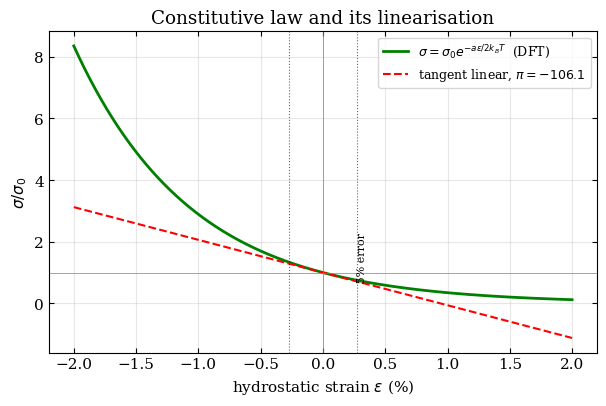

In [10]:
# `eps` is LINEAR strain throughout this notebook, so pair it with a_gap.
A_DP = a_gap

def sigma_phys(e, sigma0=1.0):
    """First-principles conductivity vs hydrostatic (linear) strain."""
    e = np.atleast_1d(e).astype(float)
    return sigma0 * np.exp(-A_DP * e / (2 * KT))

pi_eff = -A_DP / (2 * KT)

def sigma_lin(e, sigma0=1.0):
    """Tangent linear piezoresistor -- same slope at eps = 0 by construction."""
    e = np.atleast_1d(e).astype(float)
    return sigma0 * (1 + pi_eff * e)

print("Constitutive law")
print("-" * 60)
print(f"  a_gap  (linear convention)   = {A_DP:+.4f} eV")
print(f"  pi_eff = -a_gap / 2kT        = {pi_eff:+.2f}   per unit linear strain")
print(f"  (per unit VOLUMETRIC strain  = {pi_eff/3:+.2f})")
print()
print(f"  sigma(+1%) / sigma0 = {sigma_phys(+0.01)[0]:.4f}")
print(f"  sigma(-1%) / sigma0 = {sigma_phys(-0.01)[0]:.4f}")

# where does the linearisation break down?
e_fine  = np.linspace(-0.02, 0.02, 2001)
rel_err = np.abs(sigma_lin(e_fine) - sigma_phys(e_fine)) / sigma_phys(e_fine)
pos     = e_fine > 1e-6
i5      = int(np.argmax(rel_err[pos] > 0.05))
eps_linear_5pct = float(e_fine[pos][i5]) if rel_err[pos].max() > 0.05 else np.nan
print(f"\n  linear model exceeds 5% error at |eps| = {eps_linear_5pct*100:.3f}%")

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.plot(e_fine*100, sigma_phys(e_fine), '-',  color='green', lw=2,
        label=r'$\sigma=\sigma_0 e^{-a\varepsilon/2k_BT}$  (DFT)')
ax.plot(e_fine*100, sigma_lin(e_fine),  '--', color='red',  lw=1.5,
        label=rf'tangent linear, $\pi={pi_eff:.1f}$')
ax.axhline(1, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
if np.isfinite(eps_linear_5pct):
    for s in (-1, 1):
        ax.axvline(s*eps_linear_5pct*100, color='k', ls=':', lw=0.8, alpha=0.6)
    ax.text(eps_linear_5pct*100, 0.55, ' 5% error', fontsize=8, rotation=90, va='bottom')
ax.set_xlabel(r'hydrostatic strain $\varepsilon$ (%)')
ax.set_ylabel(r'$\sigma/\sigma_0$')
ax.set_title('Constitutive law and its linearisation')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIGDIR / "constitutive_law.pdf", bbox_inches="tight")
fig.savefig(FIGDIR / "constitutive_law.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Part 10 — Export

Two artifacts, deliberately separated:

- **`Hydrostatic_scalars.csv`** — long format, one row per quantity. The model
  parameters and benchmarks.
- **`Hydrostatic_sweep.csv`** — tidy table, one row per DFT strain point. The raw sweep,
  for plots and the write-up.

Sweep arrays are *not* stuffed into single cells of the scalars file: they share a common
index ($\varepsilon$), which makes them a table.

Both are written through `results_io`, which upserts by quantity name — so re-running this
cell updates only these entries and leaves other channels' files untouched.

In [11]:
# ---- guard: every per-strain-point array must have the same length ----
_lens = {"eps": len(eps), "VBM": len(VBM), "CBM": len(CBM), "gap": len(gap),
         "gap_fit": len(gap_fit), "residuals": len(residuals), "rows": len(rows)}
if len(set(_lens.values())) != 1:
    raise ValueError("Sweep arrays have inconsistent lengths:\n  "
                     + "\n  ".join(f"{k:10s} {n}" for k, n in _lens.items())
                     + "\n\nRe-run Parts 3-5 in order.")

# ---- 1. scalars ----
save_results(
    {
        # deformation potentials (this notebook's own fits, LINEAR convention)
        "a_c":       a_c,
        "a_v":       a_v,
        "a_gap":     a_gap,
        "a_vol":     a_gap / 3.0,      # volumetric convention, = literature `a`
        "a_dpt":     a_dpt,            # as stored by DPT.ipynb -- cross-check

        # equilibrium reference
        "Eg0_fit":   Eg0_fit,
        "Eg0_eq":    r_eq["gap"],
        "V0":        V0,
        "TOTEN_eq":  r_eq["TOTEN"],

        # equation of state
        "dEg_dP":    dEg_dP,
        "B_eos":     B_eos,
        "P_resid":   P_resid,

        # fit quality
        "quad_curv": quad[0],
        "resid_max": resid_max,
        "resid_rms": resid_rms,

        # transport
        "T":               T,
        "pi_eff":          pi_eff,
        "eps_linear_5pct": eps_linear_5pct,
    },
    unit={
        "a_c": "eV", "a_v": "eV", "a_gap": "eV/linear-strain",
        "a_vol": "eV/volumetric-strain", "a_dpt": "eV",
        "Eg0_fit": "eV", "Eg0_eq": "eV", "V0": "A^3", "TOTEN_eq": "eV",
        "dEg_dP": "eV/GPa", "B_eos": "GPa", "P_resid": "GPa",
        "quad_curv": "eV", "resid_max": "meV", "resid_rms": "meV",
        "T": "K", "pi_eff": "1/linear-strain", "eps_linear_5pct": "-",
    },
    source="Hydrostatic_exploration.ipynb",
    path=SCALARS,
)

# ---- 2. sweep table ----
sweep = pd.DataFrame({
    "eps":          eps,
    "VBM_aligned":  VBM,
    "CBM_aligned":  CBM,
    "gap":          gap,
    "gap_fit":      gap_fit,
    "residual_meV": residuals * 1000.0,
    "volume":       volume,
    "pressure_GPa": P_GPa,
    "TOTEN":        TOTEN,
    "E_fermi":      E_fermi,
    "V_avg":        V_avg,
    "sigma_phys":   sigma_phys(eps),
    "sigma_lin":    sigma_lin(eps),
})
save_table(sweep, SWEEP)

# ---- 3. verify the round trip ----
assert np.isclose(load_result("a_gap",  path=SCALARS), a_gap)
assert np.isclose(load_result("pi_eff", path=SCALARS), pi_eff)
_back = load_table(SWEEP)
assert len(_back) == len(eps)
assert np.allclose(_back["gap"].to_numpy(), gap)

print(f"scalars -> {SCALARS}")
print(f"sweep   -> {SWEEP}   ({len(sweep)} rows x {sweep.shape[1]} cols)")
print("round-trip verified")

scalars -> ./Hydrostatic_scalars.csv
sweep   -> ./Hydrostatic_sweep.csv   (7 rows x 13 cols)
round-trip verified


---
## Summary

In [12]:
print("=" * 66)
print("  HYDROSTATIC (Gamma_1) CHANNEL -- SUMMARY")
print("=" * 66)
print(f"  strain range            {eps.min()*100:+.1f}% .. {eps.max()*100:+.1f}%  "
      f"({len(eps)} points)")
print()
print("  DEFORMATION POTENTIALS")
print(f"    a_gap (linear)        {a_gap:+8.4f} eV")
print(f"    a_vol (volumetric)    {a_gap/3:+8.4f} eV      <- literature convention")
print(f"    a_c / a_v             {a_c:+8.4f} / {a_v:+.4f} eV   [alignment-dependent]")
print()
print("  LINEARITY")
print(f"    RMS residual          {resid_rms:8.2f} meV")
print(f"    curvature             {quad[0]:+8.2f} eV")
print()
print("  EQUATION OF STATE")
print(f"    dEg/dP                {dEg_dP:+8.5f} eV/GPa  ({dEg_dP*100:+.2f} meV/kbar)")
print(f"    B                     {B_eos:8.1f} GPa      (experiment {B_SI_LIT})")
print()
print("  TRANSPORT (intrinsic Si)")
print(f"    pi_eff                {pi_eff:+8.2f}  per unit linear strain")
print(f"    linear model to       {eps_linear_5pct*100:8.3f}% strain (5% error)")
print()
print("  SCOPE: suppressed in doped Si -- characterisation, not a device input.")
print("=" * 66)

  HYDROSTATIC (Gamma_1) CHANNEL -- SUMMARY
  strain range            -1.0% .. +1.0%  (7 points)

  DEFORMATION POTENTIALS
    a_gap (linear)         +5.4864 eV
    a_vol (volumetric)     +1.8288 eV      <- literature convention
    a_c / a_v              +8.8566 / +3.3702 eV   [alignment-dependent]

  LINEARITY
    RMS residual              0.62 meV
    curvature               -14.85 eV

  EQUATION OF STATE
    dEg/dP                -0.01281 eV/GPa  (-1.28 meV/kbar)
    B                        142.7 GPa      (experiment 97.9)

  TRANSPORT (intrinsic Si)
    pi_eff                 -106.11  per unit linear strain
    linear model to          0.272% strain (5% error)

  SCOPE: suppressed in doped Si -- characterisation, not a device input.
